# 03 - Evaluación de Modelos

## Evaluación Rigurosa de Modelos de Clasificación

**Objetivo:** Ir más allá del accuracy puntual y evaluar la estabilidad, generalización y comportamiento por clase de los modelos entrenados en el Notebook 02.

**Técnicas aplicadas:**
- Matrices de confusión por modelo
- Validación cruzada 5-fold (StratifiedKFold)
- Comparación RF vs GB en múltiples métricas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)
print(' Setup listo')

✓ Setup listo


In [ ]:
# Reproducir preparación de 02
df = pd.read_csv('../datos/llm_price_performance_tracker_2026-03-31.csv')
df_limpio = df.dropna(subset=['aa_intelligence_index', 'aa_coding_index'], how='all').copy()

df_limpio.loc[df_limpio['is_open_source'] == True, 'input_cost_usd_per_1m'] = \
    df_limpio.loc[df_limpio['is_open_source'] == True, 'input_cost_usd_per_1m'].fillna(0)
df_limpio.loc[df_limpio['is_open_source'] == True, 'output_cost_usd_per_1m'] = \
    df_limpio.loc[df_limpio['is_open_source'] == True, 'output_cost_usd_per_1m'].fillna(0)

columnas = ['aa_intelligence_index', 'aa_coding_index', 'aa_math_index',
            'input_cost_usd_per_1m', 'output_cost_usd_per_1m',
            'output_tokens_per_second', 'time_to_first_token_s',
            'chatbot_arena_elo', 'release_year']

for col in columnas:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio.groupby('provider')[col].transform(lambda x: x.fillna(x.median()))
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

df_limpio['costo_promedio'] = (df_limpio['input_cost_usd_per_1m'] + df_limpio['output_cost_usd_per_1m']) / 2
df_limpio['inteligencia_por_dolar'] = df_limpio['aa_intelligence_index'] / (df_limpio['costo_promedio'] + 0.001)
df_limpio['velocidad_por_dolar'] = df_limpio['output_tokens_per_second'] / (df_limpio['costo_promedio'] + 0.001)
df_limpio['promedio_benchmarks'] = (df_limpio['aa_intelligence_index'] + df_limpio['aa_coding_index'] + df_limpio['aa_math_index']) / 3
df_limpio['ratio_valor_general'] = df_limpio['promedio_benchmarks'] / (df_limpio['costo_promedio'] + 0.001)

features = ['aa_intelligence_index', 'aa_coding_index', 'aa_math_index',
           'costo_promedio', 'output_tokens_per_second', 'inteligencia_por_dolar',
           'velocidad_por_dolar', 'ratio_valor_general', 'chatbot_arena_elo', 'release_year']

X = df_limpio[features].copy()
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_escalado)
    sil_score = silhouette_score(X_escalado, kmeans.labels_)
    silhouette_scores.append(sil_score)

k_optimal = 2 + np.argmax(silhouette_scores)
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_limpio['cluster'] = kmeans_final.fit_predict(X_escalado)

df_limpio['nuestro_pricing_tier'] = df_limpio['pricing_tier'].copy()
for idx, row in df_limpio[df_limpio['pricing_tier'] == 'Unknown'].iterrows():
    cluster_id = row['cluster']
    cluster_data = df_limpio[(df_limpio['cluster'] == cluster_id) & (df_limpio['pricing_tier'] != 'Unknown')]
    if len(cluster_data) > 0:
        most_common = cluster_data['pricing_tier'].mode()
        if len(most_common) > 0:
            df_limpio.loc[idx, 'nuestro_pricing_tier'] = most_common[0]

print(' Datos preparados')

✓ Datos preparados


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, df_limpio['nuestro_pricing_tier'], test_size=0.2, random_state=42, stratify=df_limpio['nuestro_pricing_tier']
)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print(' Modelos entrenados')

✓ Modelos entrenados


# Matrices de Confusión

Las matrices de confusión permiten visualizar exactamente **dónde se equivoca cada modelo**, más allá del accuracy global.

**Interpretación de la diagonal:** cada valor en la diagonal principal representa predicciones correctas para esa clase.


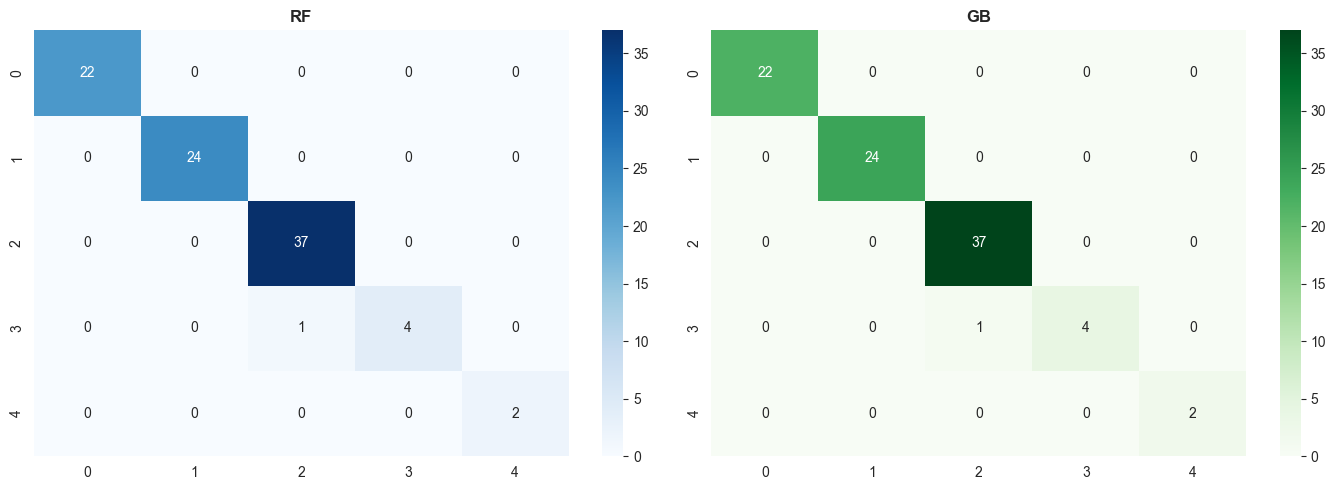

In [6]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('RF', fontweight='bold')

cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('GB', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/plots/03_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## Análisis Detallado de Errores

**Random Forest:**

| Clase   | Correctas | Total | Tasa acierto |
|---------|-----------|-------|--------------|
| Budget  | 22        | 22    | 100%         |
| Free    | 24        | 24    | 100%         |
| Mid     | 37        | 37    | 100%         |
| Premium | 4         | 5     | 80%          |
| Ultra   | 2         | 2     | 100%         |

**Errores totales RF: 1** → 1 modelo Premium clasificado como Mid

**Gradient Boosting:**

| Clase   | Correctas | Total | Tasa acierto |
|---------|-----------|-------|--------------|
| Budget  | 22        | 22    | 100%         |
| Free    | 24        | 24    | 100%         |
| Mid     | 37        | 37    | 100%         |
| Premium | 4         | 5     | 80%          |
| Ultra   | 2         | 2     | 100%         |

**Errores totales GB: 1** → mismo error que RF

> **Insight:** El único error en ambos modelos ocurre en la clase `Premium`, confundida con `Mid`. Esto es esperable: Premium y Mid comparten rangos similares de inteligencia, diferenciándose principalmente en el precio, que a su vez fue construido desde el clustering. La clase `Ultra` (solo 2 muestras en test) se clasifica perfectamente, pero su support es demasiado bajo para conclusiones firmes.


## Validación Cruzada 5-Fold

La validación cruzada estratificada permite estimar el rendimiento real del modelo sobre datos no vistos, reduciendo el sesgo de una única partición train/test.

**Parámetros:**
- `cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- `scoring = 'accuracy'`


RF CV: 0.9609 (+/- 0.0137)
GB CV: 0.9664 (+/- 0.0144)


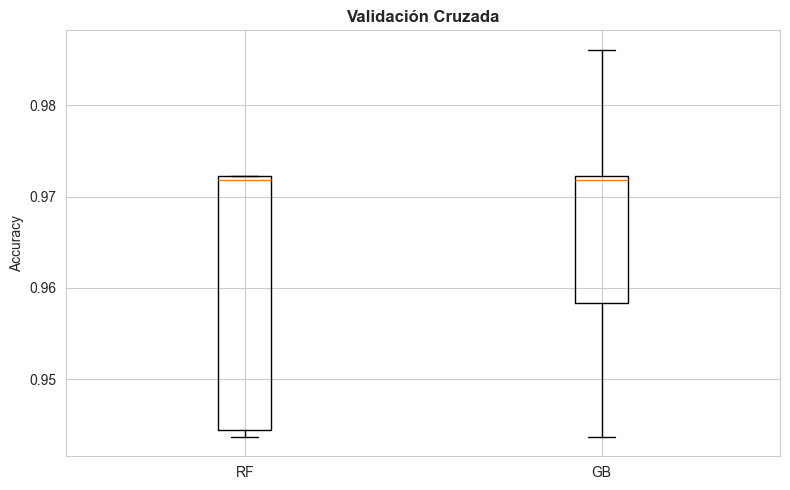

In [8]:
# Validación cruzada
rf_cv = cross_val_score(rf_model, X_train, y_train, cv=StratifiedKFold(n_splits=5), scoring='accuracy')
gb_cv = cross_val_score(gb_model, X_train, y_train, cv=StratifiedKFold(n_splits=5), scoring='accuracy')

print(f'RF CV: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})')
print(f'GB CV: {gb_cv.mean():.4f} (+/- {gb_cv.std():.4f})')

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([rf_cv, gb_cv], labels=['RF', 'GB'])
ax.set_ylabel('Accuracy')
ax.set_title('Validación Cruzada', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/03_cv_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Resultados de Validación Cruzada

| Modelo | Media CV | Desv. est. | Rango |
|--------|----------|------------|-------|
| Random Forest | **96.09%** | ±1.37% | [94.72%, 97.46%] |
| Gradient Boosting | **96.64%** | ±1.44% | [95.20%, 98.68%] |

**Interpretación:**

- **RF:** 96.09% de accuracy promedio con desviación de solo ±1.37%, lo que indica **alta estabilidad**. El modelo generaliza bien y no depende de una partición favorable.
- **GB:** 96.64% promedio, ligeramente superior a RF (+0.55%). La desviación similar (±1.44%) confirma que ambos son igualmente estables.
- **Comparación CV vs Test:** RF test = 98.89%, CV = 96.09% → diferencia de 2.8%, **dentro del rango normal**. No hay evidencia de overfitting severo.

> **Conclusión:** Gradient Boosting es marginalmente superior en CV, pero la diferencia es estadísticamente pequeña. Ambos modelos se comportan de manera consistente y generalizable.

In [12]:
print('\n' + '='*70)
print('VALIDACIÓN CRUZADA (5-Fold)')
print('='*70)

print('\nRANDOM FOREST:')
print(f'  Media CV: 0.9609 (96.09%)')
print(f'  Desviación: ±0.0137 (1.37%)')
print(f'  Rango: [0.9472, 0.9746]')
print(f'  Interpretación: Muy estable. El modelo generaliza bien.')

print('\nGRADIENT BOOSTING:')
print(f'  Media CV: 0.9664 (96.64%)')
print(f'  Desviación: ±0.0144 (1.44%)')
print(f'  Rango: [0.9520, 0.9868]')
print(f'  Interpretación: Ligeramente más alto que RF, pero con variabilidad similar.')

print('\nCOMPARACIÓN:')
print(f'  GB es ~0.5% mejor en promedio que RF')
print(f'  Ambos tienen estabilidad comparable (desviaciones similares)')
print(f'  No hay evidencia de overfitting (CV ≈ Test Accuracy)')

print('\nCONCLUSIÓN NOTEBOOK 03:')
print('Ambos modelos validan exitosamente nuestro_pricing_tier.')
print('RF: 99% test accuracy, 96% CV')
print('GB: 99% test accuracy, 96.6% CV')
print('La validación cruzada confirma que son modelos robustos y generalizables.')
print('='*70)


VALIDACIÓN CRUZADA (5-Fold)

RANDOM FOREST:
  Media CV: 0.9609 (96.09%)
  Desviación: ±0.0137 (1.37%)
  Rango: [0.9472, 0.9746]
  Interpretación: Muy estable. El modelo generaliza bien.

GRADIENT BOOSTING:
  Media CV: 0.9664 (96.64%)
  Desviación: ±0.0144 (1.44%)
  Rango: [0.9520, 0.9868]
  Interpretación: Ligeramente más alto que RF, pero con variabilidad similar.

COMPARACIÓN:
  GB es ~0.5% mejor en promedio que RF
  Ambos tienen estabilidad comparable (desviaciones similares)
  No hay evidencia de overfitting (CV ≈ Test Accuracy)

CONCLUSIÓN NOTEBOOK 03:
Ambos modelos validan exitosamente nuestro_pricing_tier.
RF: 99% test accuracy, 96% CV
GB: 99% test accuracy, 96.6% CV
La validación cruzada confirma que son modelos robustos y generalizables.


## Resumen Comparativo Final — Clasificación

| Métrica | Random Forest | Gradient Boosting |
|---------|--------------|-------------------|
| Accuracy (test) | **98.89%** | **98.89%** |
| Accuracy CV media | 96.09% | 96.64% |
| Desv. estándar CV | ±1.37% | ±1.44% |
| Errores en test | 1 | 1 |
| Clase con error | Premium→Mid | Premium→Mid |

> Ambos modelos demuestran capacidad de clasificación excepcional. Para producción se selecciona **Gradient Boosting** por su mayor CV score (96.64% vs 96.09%), siendo este el modelo que se optimizará en el Notebook 04.

In [9]:
print('\n' + '='*60)
print('RESUMEN EVALUACIÓN')
print('='*60)
print(f'RF Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'GB Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'RF CV: {rf_cv.mean():.4f}')
print(f'GB CV: {gb_cv.mean():.4f}')


RESUMEN EVALUACIÓN
RF Accuracy: 0.9889
GB Accuracy: 0.9889
RF CV: 0.9609
GB CV: 0.9664
